## Part (a):

# Import

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters

In [39]:
mu_max = 0.3        # h^{-1}
K_s = 0.8           # g glucose / L
K_I = 100           # g glucose / L
Y_XS = 0.45         # g cells / g glucose
Y_XP = 0.15         # g cells / g product
S0 = SP =80         # g glucose / L

# Initial conditions

In [40]:
V0 = 0.85           # L
X0 = 30             # g cells / L
S_init = 0          # negligible glucose
P_init = 0          # g product / L
NX0 = X0 * V0       # g cells
NS0 = S_init * V0   # g glucose
NP0 = P_init * V0   # g product
y0 = [NX0, NS0, NP0, V0]

# Functions

In [41]:
# Growth rate with substrate inhibition
def mu_net(S):
    return mu_max * S / (K_s + S + S**2 / K_I)

# ODE system

def fed_batch_odes(t, y):
    NX, NS, NP, V = y
    
    X = NX / V
    S = NS / V
    P = NP / V
    
    mu = mu_net(S)
    
    # Operating mode
    if t <= 1:
        F_in = 0.2
        S_in = S0
        F_out = 0
        
    elif t <= 6:
        F_in = 0.5
        S_in = SP
        F_out = 0
        
    else:
        F_in = 0
        S_in = 0
        F_out = 2.5
    
    dNXdt = mu * X * V - F_out * X
    dNSdt = F_in * S_in - (mu * X * V) / Y_XS - F_out * S
    dNPdt = (mu * X * V) / Y_XP - F_out * P
    dVdt = F_in - F_out
    
    return [dNXdt, dNSdt, dNPdt, dVdt]

# Numerical Resolution

In [42]:
t_span = (0, 7)
t_eval = np.linspace(0, 7, 1000)

sol = solve_ivp(fed_batch_odes, t_span, y0, t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-10)

t = sol.t
NX, NS, NP, V = sol.y

X = NX / V
S = NS / V
P = NP / V

# Plot

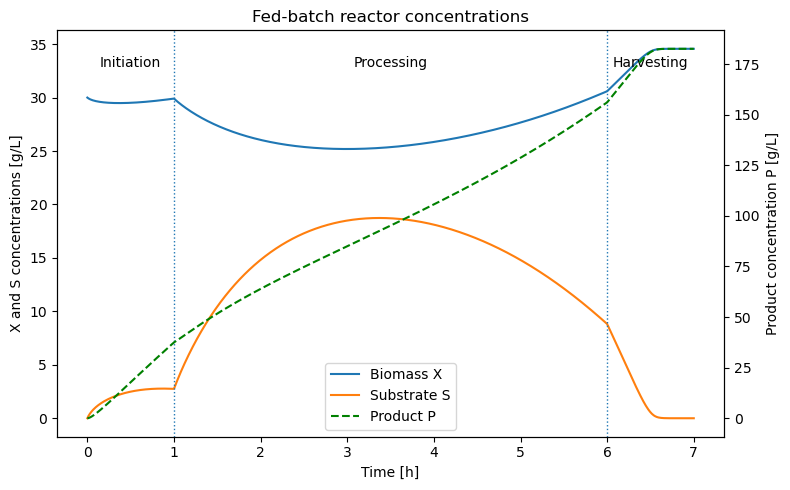

In [43]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(t, X, label="Biomass X")
ax1.plot(t, S, label="Substrate S")
ax1.set_xlabel("Time [h]")
ax1.set_ylabel("X and S concentrations [g/L]")

ax2 = ax1.twinx()
ax2.plot(t, P, linestyle="--", color = "green", label="Product P")
ax2.set_ylabel("Product concentration P [g/L]")

ax1.axvline(1, linestyle=":", linewidth=1)
ax1.axvline(6, linestyle=":", linewidth=1)

ax1.text(0.5, max(X)*0.95, "Initiation", ha="center")
ax1.text(3.5, max(X)*0.95, "Processing", ha="center")
ax1.text(6.5, max(X)*0.95, "Harvesting", ha="center")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Fed-batch reactor concentrations")
plt.tight_layout()
plt.show()

# Final values

In [44]:
print(f"Final volume at t = 7 h: {V[-1]:.3f} L")
print(f"Final biomass concentration X: {X[-1]:.3f} g/L")
print(f"Final substrate concentration S: {S[-1]:.3f} g/L")
print(f"Final product concentration P: {P[-1]:.3f} g/L")

Final volume at t = 7 h: 1.050 L
Final biomass concentration X: 34.563 g/L
Final substrate concentration S: 0.000 g/L
Final product concentration P: 182.535 g/L


# Part (b):

# Function

In [45]:
def fed_batch_odes_cycles(t, y):
    NX, NS, NP, V = y
    
    X = NX / V
    S = NS / V
    P = NP / V
    
    mu = mu_net(S)
    
    # Initiation:
    if t <= 1:
        F_in = 0.2
        S_in = S0
        F_out = 0
    
    # Repeated processing/harvesting cycles after initiation
    else:
        tau = (t - 1) % 6   # one cycle = 5 h processing + 1 h harvesting
        
        if tau < 5:
            # Processing: t_i < t <= t_P
            F_in = 0.5
            S_in = SP
            F_out = 0
        else:
            # Harvesting: t_P < t <= t_H
            F_in = 0
            S_in = 0
            F_out = 2.5
    
    dNXdt = mu * X * V - F_out * X
    dNSdt = F_in * S_in - (mu * X * V) / Y_XS - F_out * S
    dNPdt = (mu * X * V) / Y_XP - F_out * P
    dVdt = F_in - F_out
    
    return [dNXdt, dNSdt, dNPdt, dVdt]

# Numerical Resolution

In [46]:
n_cycles = 10

t_start = 0
t_end = 1 + n_cycles * 6   # initiation + 10 cycles of 6 h

t_eval_b = np.linspace(t_start, t_end, 5000)

sol_b = solve_ivp(fed_batch_odes_cycles, (t_start, t_end), y0, t_eval=t_eval_b, method="RK45", rtol=1e-8, atol=1e-10)

t_b = sol_b.t
NX_b, NS_b, NP_b, V_b = sol_b.y

X_b = NX_b / V_b
S_b = NS_b / V_b
P_b = NP_b / V_b

# Plot

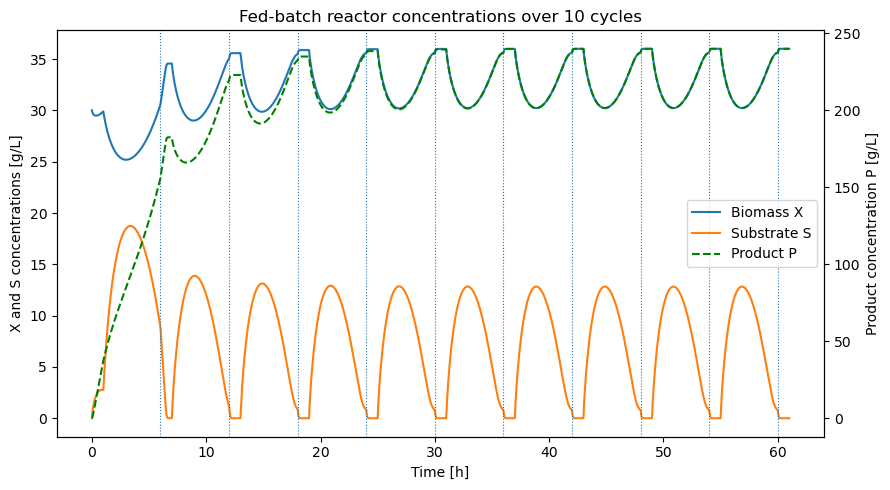

In [47]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(t_b, X_b, label="Biomass X")
ax1.plot(t_b, S_b, label="Substrate S")

ax1.set_xlabel("Time [h]")
ax1.set_ylabel("X and S concentrations [g/L]")

ax2 = ax1.twinx()
ax2.plot(t_b, P_b, linestyle="--", color = "green", label="Product P")
ax2.set_ylabel("Product concentration P [g/L]")

# Vertical lines at the beginning of each harvesting step
for i in range(n_cycles):
    t_harvest_start = 1 + 5 + i * 6
    ax1.axvline(t_harvest_start, linestyle=":", linewidth=0.8)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Fed-batch reactor concentrations over 10 cycles")
plt.tight_layout()
plt.show()

# Production rate during the 10th cycle

In [48]:
cycle_number = 10

t_cycle_start = 1 + (cycle_number - 1) * 6
t_harvest_start = t_cycle_start + 5
t_cycle_end = t_cycle_start + 6

# Product mass at the beginning and end of the 10th harvesting step
NP_harvest_start = np.interp(t_harvest_start, t_b, NP_b)
NP_cycle_end = np.interp(t_cycle_end, t_b, NP_b)

# Product harvested during the 10th harvesting step
P_harvested_10 = NP_harvest_start - NP_cycle_end

cycle_time = 6   # h
production_rate = P_harvested_10 / cycle_time

print(f"Start of 10th cycle: {t_cycle_start:.2f} h")
print(f"Start of 10th harvest: {t_harvest_start:.2f} h")
print(f"End of 10th cycle: {t_cycle_end:.2f} h")
print()
print(f"Product mass before 10th harvest: {NP_harvest_start:.3f} g")
print(f"Product mass after 10th harvest: {NP_cycle_end:.3f} g")
print(f"Product harvested during 10th cycle: {P_harvested_10:.3f} g")
print(f"Production rate: {production_rate:.3f} g/h")

Start of 10th cycle: 55.00 h
Start of 10th harvest: 60.00 h
End of 10th cycle: 61.00 h

Product mass before 10th harvest: 843.052 g
Product mass after 10th harvest: 251.999 g
Product harvested during 10th cycle: 591.053 g
Production rate: 98.509 g/h
